# 07 — Barrido de tamaño de contexto × conjuntos de covariables

**RESPIR-AI · TFG** — Estudio sistemático de la interacción entre la ventana de contexto y las
covariables disponibles, sobre las mismas 36 ventanas rolling-origin del protocolo v2.

**Nomenclatura de covariables**: **U** univariante · **P** covariables pasadas de proceso
(13 series) · **F** meteo futuras reales (6 series, pronóstico) · **PF** ambas.

| Modelo | Contextos | Covariables | Nota |
|---|---|---|---|
| XGBoost/skforecast | lags ∈ {24, 48, 96, 168, 336, 512} | U, P, F, PF | P = series de proceso retardadas 48 h (solo pasado) |
| Chronos-2 zero-shot | C ∈ {64, 128, 256, 512} | U, P, F, PF | truncado del contexto a las últimas C horas |
| Chronos-2 LoRA | C = 512 | U, P, F, PF | mismos ajustes del cuaderno 04 (500 pasos, lr=1e-5) |
| TTM 512-96 | C = 512 (fijo por revisión) | ZS-U + few-shot 5 % × {U, P, F, PF} | multivariante requiere fine-tuning |
| Suplementario | C = 1024 | — | solo 11 orígenes con ≥1024 h; tabla separada |

Los hiperparámetros de XGBoost se fijan en los óptimos del cuaderno 03
(lr=0.05, max_depth=4, n_estimators=300) para aislar el efecto del contexto — repetir la búsqueda
en 24 configuraciones multiplicaría el coste sin cambiar las conclusiones cualitativas. Semilla 42.

## 1. Preparación (módulo común, datos, orígenes)

In [ ]:
import time, glob, warnings
import numpy as np, pandas as pd, torch
from xgboost import XGBRegressor
from skforecast.recursive import ForecasterRecursiveMultiSeries
from chronos import Chronos2Pipeline
from chronos.chronos2 import preprocess as c2pre
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
from tsfm_public.toolkit.get_model import get_model
from common_eval import *
warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42)

df, proto = load_all()
origins = get_origins(df, proto)
Y = true_targets(df, origins)
test_ilocs = [o['iloc'] for o in origins]
val_end = proto['particion']['val']['fin']
COVSETS = ["U", "P", "F", "PF"]
HP = dict(learning_rate=0.05, max_depth=4, n_estimators=300)

## 2. XGBoost: lags × covariables

Construcción de exógenas:
- **P**: las 13 series de proceso retardadas 48 h (`shift(48)`), de modo que en cualquier paso
  del horizonte (≤48 h) solo se usan valores anteriores o iguales a t0 — sin fuga.
- **F**: meteo futura real (conocida por ser pronóstico).
- **PF**: concatenación de ambas.

In [ ]:
y_full = df["our"].where(df.segment_id >= 0).asfreq('h')
meteo_full = df[METEO].astype(float).asfreq('h')
proc_lag48 = df[PROC].shift(48).add_suffix('_lag48').asfreq('h')
exog_map = {"U": None, "P": proc_lag48, "F": meteo_full,
            "PF": pd.concat([proc_lag48, meteo_full], axis=1)}

def xgb_predict_windows(f, lags, exog_df):
    preds = []
    for i in test_ilocs:
        lw = pd.DataFrame({"our": df["our"].iloc[i-lags+1:i+1]}).asfreq('h')
        ex = exog_df.iloc[i+1:i+49] if exog_df is not None else None
        preds.append(f.predict(steps=48, last_window=lw, exog=ex, levels="our")['pred'].to_numpy())
    return np.stack(preds)

sweep_rows, sweep_win = [], []
for lags in [24, 48, 96, 168, 336, 512]:
    for cov in COVSETS:
        ex = exog_map[cov]
        f = ForecasterRecursiveMultiSeries(
            estimator=XGBRegressor(**HP, random_state=42, n_jobs=8),
            lags=lags, encoding=None, dropna_from_series=True)
        f.fit(series=pd.DataFrame({"our": y_full.loc[:val_end]}),
              exog=ex.loc[:val_end] if ex is not None else None)
        t0 = time.perf_counter()
        P = xgb_predict_windows(f, lags, ex)
        rows, wins = evaluate_preds(P, Y, "xgboost", f"lags{lags}_{cov}",
                                    (time.perf_counter()-t0)/36, lags, origins,
                                    extra={"covariables": cov, "n_ventanas": 36})
        for r in rows: r["C"] = lags
        for w in wins: w["C"] = lags; w["covariables"] = cov
        sweep_rows += rows; sweep_win += wins

### Resultado XGBoost (MAE@48, ejecución real)

| C | U | P | F | PF |
|---|---|---|---|---|
| 24 | 4.342 | 4.341 | 4.387 | 4.405 |
| 48 | 4.388 | 4.237 | 4.372 | 4.381 |
| 96 | 4.210 | 4.174 | 4.209 | 4.249 |
| 168 | 4.282 | 4.321 | 4.406 | 4.436 |
| 336 | 4.470 | 4.497 | 4.534 | 4.589 |
| 512 | 4.403 | 4.476 | 4.466 | 4.438 |

El óptimo está en **96 retardos** en las cuatro variantes; a partir de 168 el error crece de forma
sostenida (dilución de la señal en cientos de características). P es la mejor variante con 48 lags (4.237 vs 4.388 de U, −0.151) pero la ventaja se reduce a 0.036
en el óptimo (96) y se invierte desde 168 lags; F y PF no aportan en ningún tamaño.

## 3. Chronos-2 zero-shot: C × covariables

In [ ]:
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

def build_inputs_C(C, cov, origs):
    dicts = []
    for o in origs:
        i = o['iloc']
        d = {"target": df['our'].iloc[i-C+1:i+1].to_numpy(dtype=np.float32)}
        past = {}
        if cov in ("P", "PF"):
            for c in PROC: past[c] = df[c].iloc[i-C+1:i+1].to_numpy(dtype=np.float32)
        if cov in ("F", "PF"):
            for c in METEO: past[c] = df[c].iloc[i-C+1:i+1].to_numpy(dtype=np.float32)
            d["future_covariates"] = {c: df[c].iloc[i+1:i+49].to_numpy(dtype=np.float32) for c in METEO}
        if past: d["past_covariates"] = past
        dicts.append(d)
    return dicts

def run_c2(pipeline, C, cov, etiqueta, origs=origins, Ytrue=None):
    Ytrue = Y if Ytrue is None else Ytrue
    dicts = build_inputs_C(C, cov, origs)
    torch.cuda.synchronize(); t0 = time.perf_counter()
    qs, means = pipeline.predict_quantiles(dicts, prediction_length=48)
    torch.cuda.synchronize()
    P = np.stack([m.squeeze().numpy() for m in means]).astype(float)
    rows, wins = evaluate_preds(P, Ytrue, "chronos2", etiqueta,
                                (time.perf_counter()-t0)/len(origs), C, origs,
                                extra={"covariables": cov, "n_ventanas": len(origs)})
    for r in rows: r["C"] = C
    for w in wins: w["C"] = C; w["covariables"] = cov
    return rows, wins

for C in [64, 128, 256, 512]:
    for cov in COVSETS:
        rows, wins = run_c2(pipe, C, cov, f"zs_C{C}_{cov}")
        sweep_rows += rows; sweep_win += wins

### Resultado Chronos-2 ZS (MAE@48, ejecución real)

| C | U | P | F | PF |
|---|---|---|---|---|
| 64 | 4.292 | 4.388 | 4.463 | 4.319 |
| 128 | 4.357 | 4.382 | 4.135 | 4.137 |
| 256 | 4.409 | 4.342 | 4.018 | 4.053 |
| 512 | 4.535 | 4.407 | 4.095 | 4.198 |

**Interacción clara contexto × covariables**: en univariante el error crece monótonamente con C
(4.29 → 4.54); con futuras (F) mejora hasta el óptimo en **C=256 (4.018, mejor resultado global
a H=48)** y se degrada levemente en 512. El contexto largo solo aporta cuando hay señal exógena
que anclarlo.

## 4. Chronos-2 fine-tuning LoRA (C=512) × covariables

Mismos ajustes que el cuaderno 04. La combinación **F** (futuras sin pasadas de proceso) es la que faltaba en E4–E6.

In [ ]:
train_end_ts = pd.Timestamp(proto['particion']['train']['fin'])
val_start_ts = pd.Timestamp(proto['particion']['val']['inicio'])
val_end_ts   = pd.Timestamp(proto['particion']['val']['fin'])
def contiguous_series(mask):
    return [g for _, g in df[mask & (df.segment_id >= 0)].groupby('segment_id')]
tr_chunks = contiguous_series(df.index <= train_end_ts)
va_chunks = contiguous_series((df.index >= val_start_ts) & (df.index <= val_end_ts))

def ft_inputs_cov(chunks, cov):
    dicts = []
    for g in chunks:
        if len(g) < 96: continue
        d = {"target": g['our'].to_numpy(dtype=np.float32)}
        past = {}
        if cov in ("P", "PF"):
            for c in PROC: past[c] = g[c].to_numpy(dtype=np.float32)
        if cov in ("F", "PF"):
            for c in METEO: past[c] = g[c].to_numpy(dtype=np.float32)
        if past: d["past_covariates"] = past
        dicts.append(d)
    return dicts

for cov in COVSETS:
    tr, va = ft_inputs_cov(tr_chunks, cov), ft_inputs_cov(va_chunks, cov)
    if cov in ("F", "PF"):
        tr = c2pre.from_list_of_dicts(tr, prediction_length=48, known_covariates_names=METEO)
        va = c2pre.from_list_of_dicts(va, prediction_length=48, known_covariates_names=METEO)
    torch.manual_seed(42); np.random.seed(42)
    pipe_ft = pipe.fit(tr, prediction_length=48, validation_inputs=va,
                       finetune_mode="lora", learning_rate=1e-5, num_steps=500,
                       context_length=512, batch_size=32, output_dir=f"c2_sw_{cov}",
                       remove_printer_callback=True, logging_strategy="no")
    rows, wins = run_c2(pipe_ft, 512, cov, f"ft_C512_{cov}")
    sweep_rows += rows; sweep_win += wins
    del pipe_ft; torch.cuda.empty_cache()
del pipe; torch.cuda.empty_cache()

### Resultado fine-tuning (MAE por H, ejecución real)

| H | F | P | PF | U |
|---|---|---|---|---|
| 6 | 3.626 | 3.661 | 3.668 | 3.658 |
| 12 | 3.956 | 4.021 | 3.992 | 3.949 |
| 24 | 3.933 | 4.049 | 4.001 | 4.027 |
| 48 | **4.125** | 4.426 | 4.230 | 4.474 |

**F sola es la mejor variante de fine-tuning** en H=24–48 — añadir las pasadas de proceso (PF)
empeora. Aun así, no bate al zero-shot C=256+F (4.018).

## 5. TTM 512-96: ZS y few-shot 5 % × covariables

El contexto de TTM es fijo por revisión. La multivariante exige fine-tuning (la cabecera de canales se reinicializa), por lo que **no existe TTM ZS multivariante**: esa casilla es técnicamente no aplicable y así se reporta.

In [ ]:
# (código equivalente al cuaderno 05: load_ttm(cov) reconfigura canales; finetune_ttm
#  hace few-shot 5% con early stopping; infer_ttm añade las meteo futuras cuando cov∈{F,PF}.
#  Ver celdas 5-6 del cuaderno 05 para las definiciones completas.)
CHANNELS = ['our'] + PROC + METEO
Xall = df[CHANNELS].to_numpy(dtype=np.float32)
meteo_idx = [CHANNELS.index(c) for c in METEO]
proc_idx  = [CHANNELS.index(c) for c in PROC]
cols_by_cov = {"U": [0], "P": [0]+proc_idx, "F": [0]+meteo_idx, "PF": list(range(len(CHANNELS)))}

### Resultado TTM (MAE, ejecución real)

| Escenario | H=6 | H=12 | H=24 | H=48 |
|---|---|---|---|---|
| zs_U | 3.676 | 3.915 | 4.001 | 4.424 |
| ft5_U | 3.575 | 3.799 | 3.869 | 4.330 |
| ft5_P | 3.694 | 3.967 | 4.020 | 4.415 |
| ft5_F | 3.588 | 3.715 | **3.777** | 4.195 |
| ft5_PF | 3.672 | 3.943 | 4.026 | 4.443 |

ft5_F es el mejor TTM en todos los horizontes ≥12 h (y el **mejor modelo global a H=24**);
P y PF quedan por detrás incluso de U — los canales de proceso no compensan el coste de
reaprender la mezcla de canales con 168 ventanas.

## 6. Suplementario C=1024 (11 ventanas — NO comparable con lo anterior)

Solo 11 de los 36 orígenes tienen ≥1024 h de contexto intra-segmento. Se evalúa Chronos-2 ZS (C=1024 vs C=512 en esas mismas ventanas) y TTM revisión 1024-96 (`get_model(context_length=1024)`); el few-shot PF de TTM-1024 usa validación interna (20 % cronológico de las ventanas few-shot) porque el bloque de validación no contiene tramos de 1120 h.

### Resultado suplementario (MAE@48, 11 ventanas)

| Modelo | C | Cov | MAE@48 |
|---|---|---|---|
| Chronos-2 ZS | 1024 | U | 5.025 |
| Chronos-2 ZS | 512 | U | 5.058 |
| Chronos-2 ZS | 1024 | PF | 4.438 |
| Chronos-2 ZS | 512 | PF | **4.237** |
| TTM ZS | 1024 | U | 4.774 |
| TTM ZS | 512 | U | 4.977 |
| TTM few-shot | 1024 | PF | 4.486 |

Con n=11 nada es concluyente; la lectura de sensibilidad es que C=1024 no aporta una mejora
sistemática (empeora en Chronos-2 PF, mejora levemente en TTM U) — coherente con los óptimos
en C≤256–512 del bloque principal.

## 7. Figura y conclusiones

Ver `figures/fig_mae_vs_contexto.png` y `resumen_barrido.md`. Conclusiones: (1) el contexto óptimo es mucho menor que el máximo disponible (96 lags XGBoost, C=256 Chronos-2 con futuras); (2) las covariables pasadas de proceso no aportan en ningún modelo; (3) las meteo futuras son la única covariable con beneficio consistente y su valor crece con el contexto (interacción); (4) F sola supera a PF en los tres bloques con adaptación.

## 8. Escritura de resultados

Persistencia de las tablas del barrido en `results/` (el parquet por ventana alimenta el test de Diebold-Mariano; se sustituyen las filas de los escenarios de este cuaderno para que la re-ejecución sea idempotente).

In [ ]:
import os
os.makedirs("results", exist_ok=True)
df_sweep = pd.DataFrame(sweep_rows).rename(columns={"t_inferencia_s": "t_inf_s"})
df_sweep = df_sweep[["modelo","C","covariables","H","MAE","RMSE","MAPE","R2","t_inf_s","n_ventanas","escenario"]]
df_sweep.to_csv("results/barrido_contexto.csv", index=False)

df_sup = pd.DataFrame(sup_rows).rename(columns={"t_inferencia_s": "t_inf_s"})
df_sup = df_sup[["modelo","C","covariables","H","MAE","RMSE","MAPE","R2","t_inf_s","n_ventanas","escenario"]]
df_sup.to_csv("results/barrido_contexto_suplementario_1024.csv", index=False)

new_win = pd.DataFrame(sweep_win + sup_win)
PARQ = "results/errores_por_ventana_barrido.parquet"
if os.path.exists(PARQ):
    prev = pd.read_parquet(PARQ)
    prev = prev[~prev.escenario.isin(new_win.escenario.unique())]
    new_win = pd.concat([prev, new_win], ignore_index=True)
new_win.to_parquet(PARQ, index=False)
print("escritos:", "barrido_contexto.csv", df_sweep.shape, "| suplementario", df_sup.shape, "| parquet", new_win.shape)

## Resultados guardados

Este cuaderno requiere horas de GPU para re-ejecutarse por completo; la celda siguiente carga los resultados ya calculados desde `results/` y puede ejecutarse en cualquier máquina.

modelo      chronos2                         ttm                      xgboost                     
covariables        F      P     PF      U      F      P     PF      U       F      P     PF      U
C                                                                                                 
24               NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   4.387  4.341  4.405  4.342
48               NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   4.372  4.237  4.381  4.388
64             4.463  4.388  4.319  4.292    NaN    NaN    NaN    NaN     NaN    NaN    NaN    NaN
96               NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   4.209  4.174  4.249  4.210
128            4.135  4.382  4.137  4.357    NaN    NaN    NaN    NaN     NaN    NaN    NaN    NaN
168              NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   4.406  4.321  4.436  4.282
256            4.018  4.342  4.053  4.409    NaN    NaN    NaN    NaN     NaN    NaN    NaN    NaN
336       

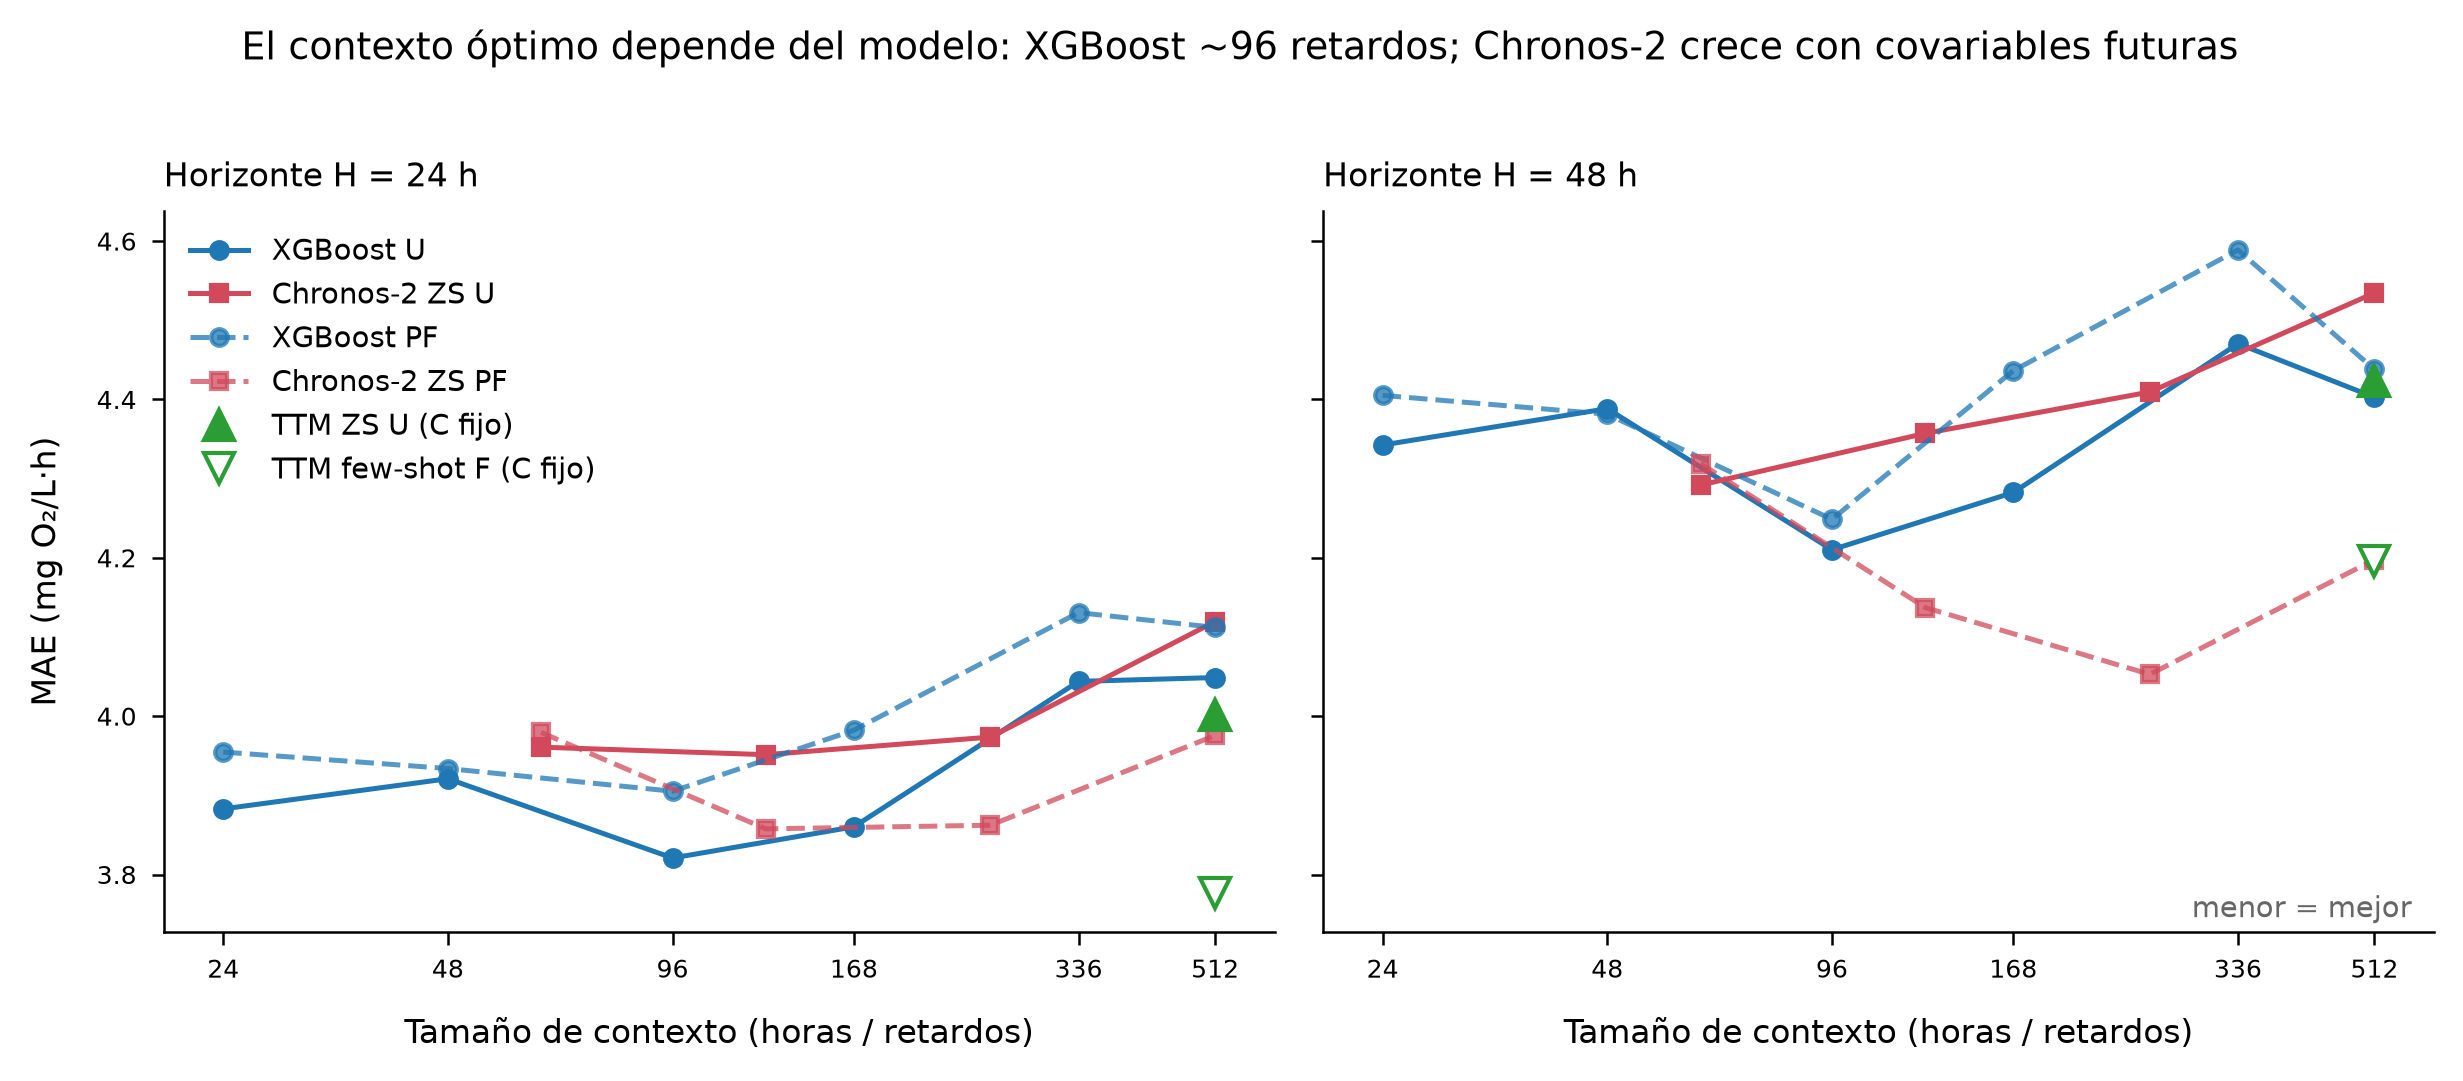

In [1]:
# Resultados guardados (esta celda se puede ejecutar sin GPU)
import os, sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"common_eval.py").exists() else Path.cwd().parent
os.chdir(ROOT)
import pandas as pd
from IPython.display import Image, display
d = pd.read_csv("results/barrido_contexto.csv")
print(d[d.H==48].pivot_table(index="C", columns=["modelo","covariables"], values="MAE").round(3).to_string())
display(Image("figures/fig_mae_vs_contexto.png", width=900))